# Weather Forecasting with Python
Weather prediction is a core use case of time series analysis in Data Science. By learning patterns from historical observations, we can build models that estimate future conditions for a specific place and time. In this project, we will guide you through preparing data, exploring trends and seasonality, and training forecasting models in Python.

<div align="center">
<img src="https://cdn.britannica.com/45/231245-050-D7E2EA32/weather-map-meteorology.jpg" />
</div>

## What Is Weather Forecasting?
Weather forecasting means predicting future atmospheric conditions—such as temperature, humidity, and rainfall—for a given location and horizon. Using time‑stamped weather records and appropriate algorithms, we can produce multi‑day forecasts.

To make this concrete, we'll work with a publicly available dataset containing daily climate observations from New Delhi. You can download it from [this Kaggle dataset](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data).

Next, we'll load, analyze, and model the data to generate weather forecasts using Python.

## 1. Importing Libraries
First, let's import the necessary libraries for data manipulation, visualization, and time series analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from prophet import Prophet
from prophet.plot import plot_plotly

import warnings

### Configuration
Let's configure the necessary settings.

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Data Loading
Next, we will load the dataset into a pandas DataFrame and take a quick look at its structure.

In [3]:
df = pd.read_csv('DailyDelhiClimateTrain.csv')

In [4]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
df.shape

(1462, 5)

## 3. Data Visualization
Let's visualize the data to understand it better.

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1462,2015-01-01 12:00:00,2013-01-01 00:00:00,2014-01-01 06:00:00,2015-01-01 12:00:00,2016-01-01 18:00:00,2017-01-01 00:00:00,NaN
meantemp,1462.0,25.495521,6.0,18.857143,27.714286,31.305804,38.714286,7.348103
humidity,1462.0,60.771702,13.428571,50.375,62.625,72.21875,100.0,16.769652
wind_speed,1462.0,6.802209,0.0,3.475,6.221667,9.238235,42.22,4.561602
meanpressure,1462.0,1011.104548,-3.041667,1001.580357,1008.563492,1014.944901,7679.333333,180.231668


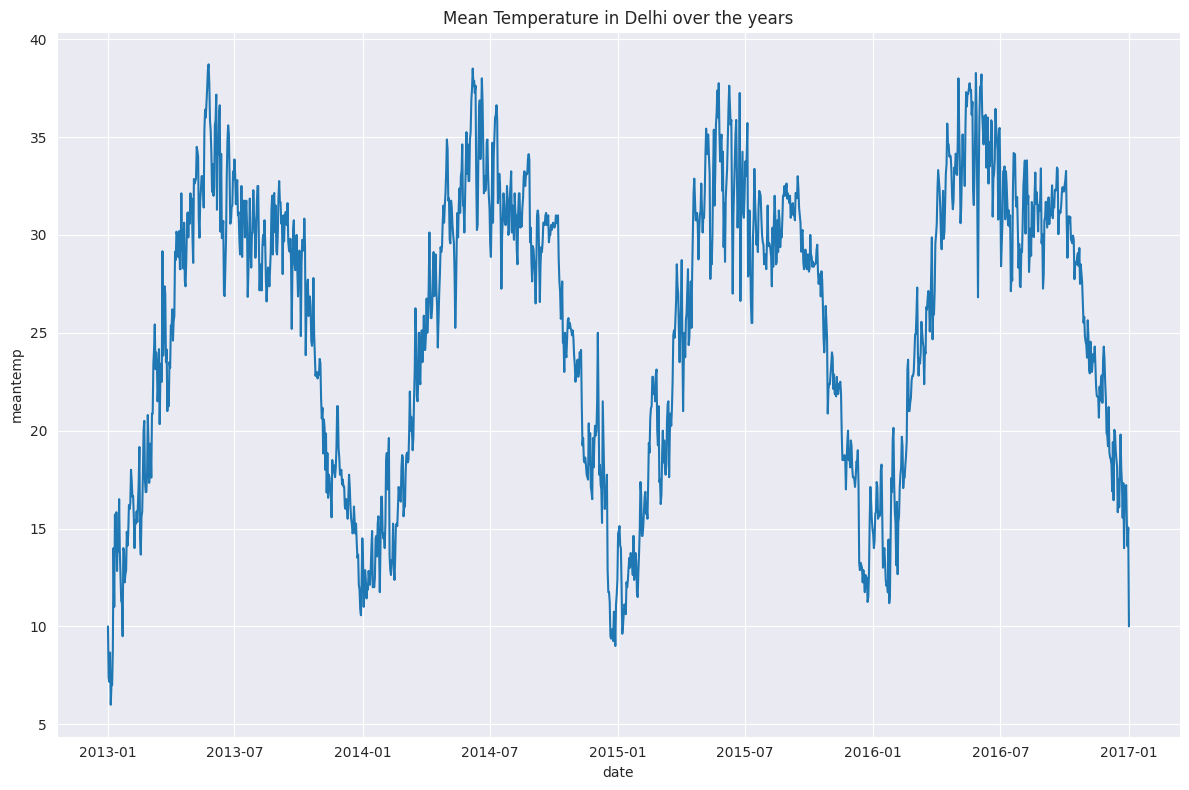

In [9]:
sns.lineplot(df, x='date', y='meantemp')
plt.title('Mean Temperature in Delhi over the years')
plt.tight_layout()

In [10]:
# Interactive plot with plotly
px.line(df, x='date', y='meantemp', title='Mean Temperature in Delhi over the years')

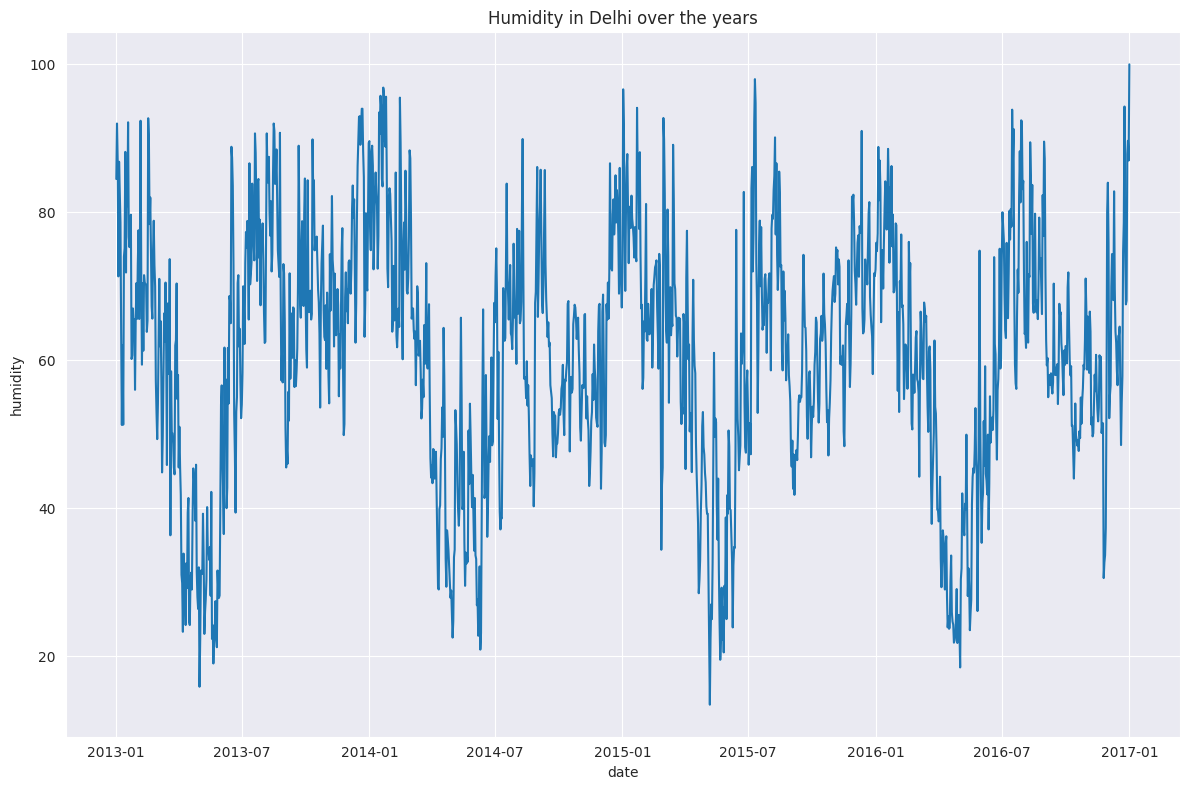

In [11]:
sns.lineplot(df, x='date', y='humidity')
plt.title('Humidity in Delhi over the years')
plt.tight_layout()

In [12]:
# Interactive plot with plotly
px.line(df, x='date', y='humidity', title='Humidity in Delhi over the years')

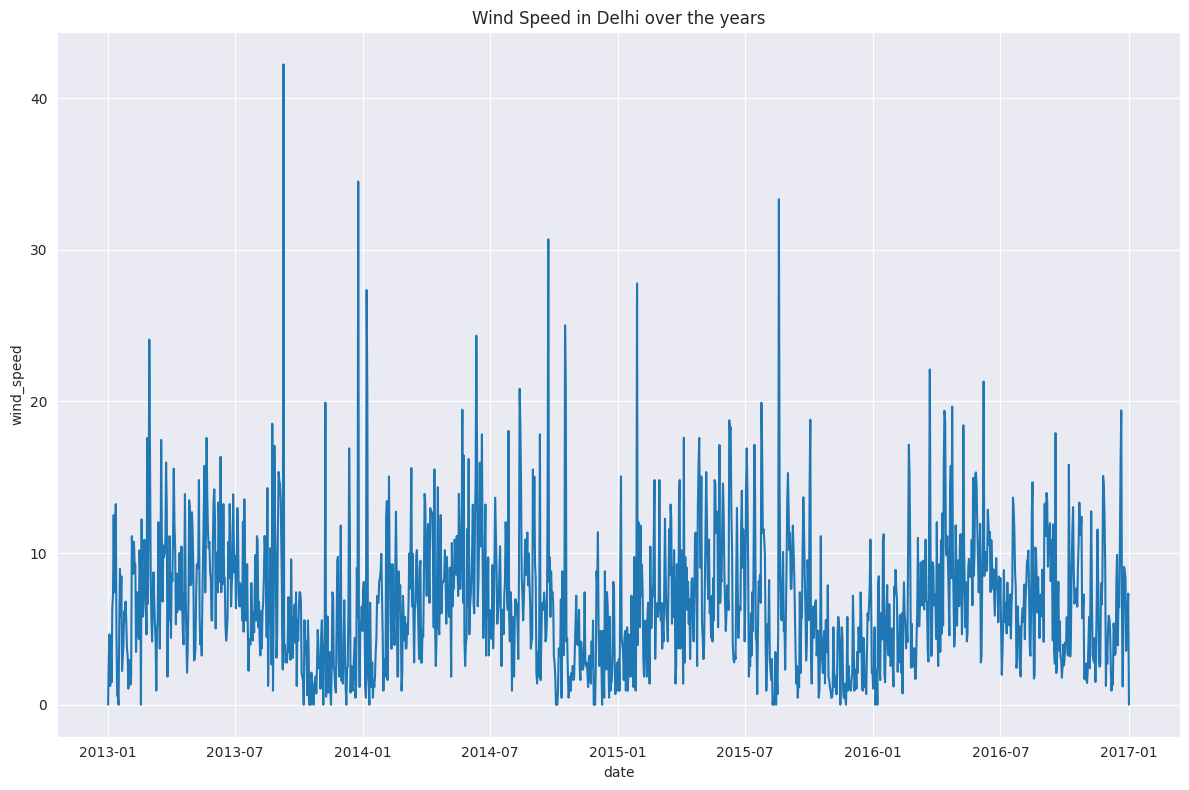

In [13]:
sns.lineplot(df, x='date', y='wind_speed')
plt.title('Wind Speed in Delhi over the years')
plt.tight_layout()

In [14]:
# Interactive plot with plotly
px.line(df, x='date', y='wind_speed', title='Wind Speed in Delhi over the years')

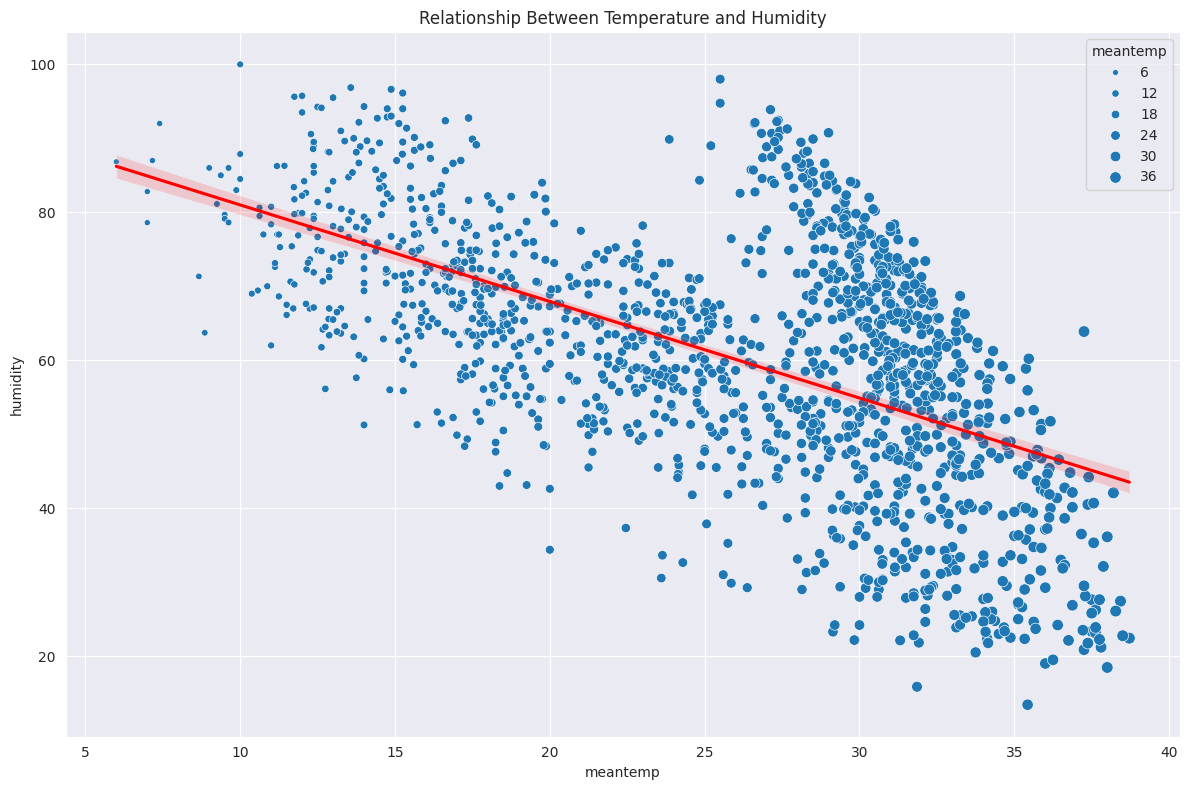

In [15]:
sns.scatterplot(df, x='meantemp', y='humidity', size='meantemp')
sns.regplot(df, x='meantemp', y='humidity', scatter=False, color='red')
plt.title('Relationship Between Temperature and Humidity')
plt.tight_layout()

In [16]:
# Interactive plot with plotly
px.scatter(
    df, 
    x='meantemp', 
    y='humidity', 
    size='meantemp', 
    trendline='ols',
    trendline_color_override='red',
    title='Relationship Between Temperature and Humidity'
)

In [17]:
df.corr(numeric_only=True)

,meantemp,humidity,wind_speed,meanpressure
meantemp,1.000000,-0.571951,0.306468,-0.038818
humidity,-0.571951,1.000000,-0.373972,0.001734
wind_speed,0.306468,-0.373972,1.000000,-0.020670
meanpressure,-0.038818,0.001734,-0.020670,1.000000


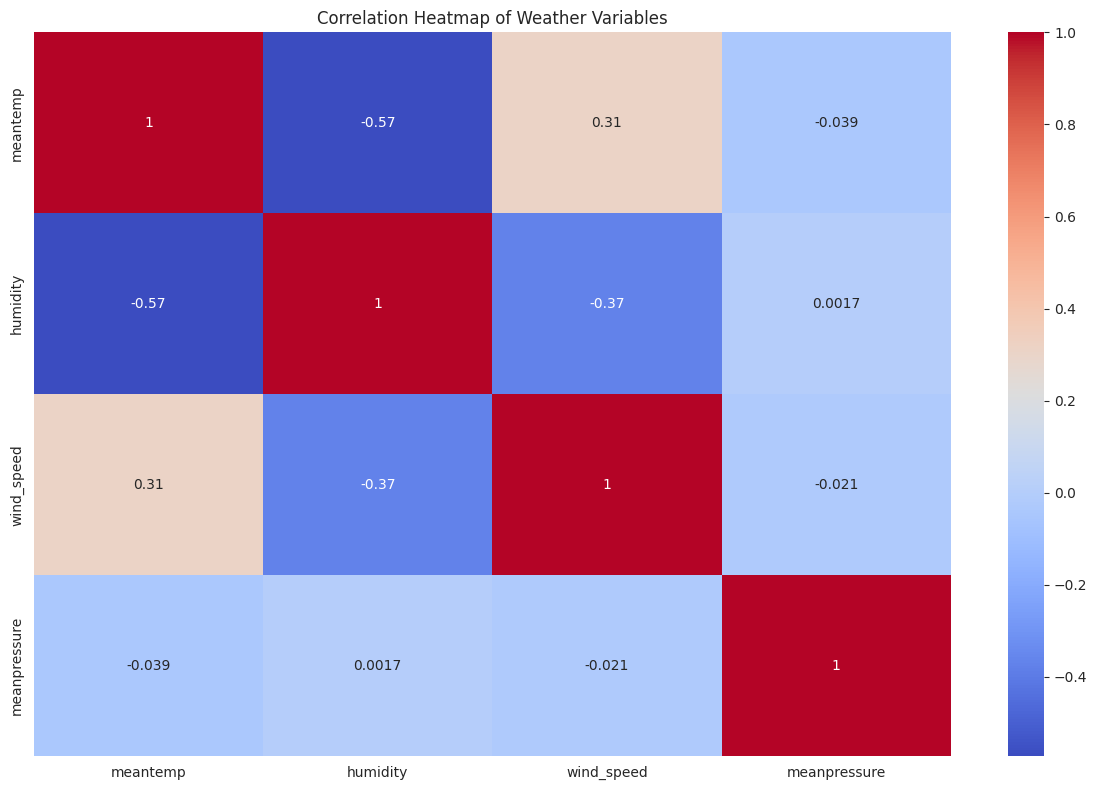

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Weather Variables')
plt.tight_layout()

There's negative correlation between temperature and humidity in Delhi. It means that when the temperature is higher, the humidity is lower.

### Analyzing Temperature Change
Now let's analyze the temperature change over the years. I will add two new columns to the dataframe: `year` and `month`.

In [19]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [20]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1


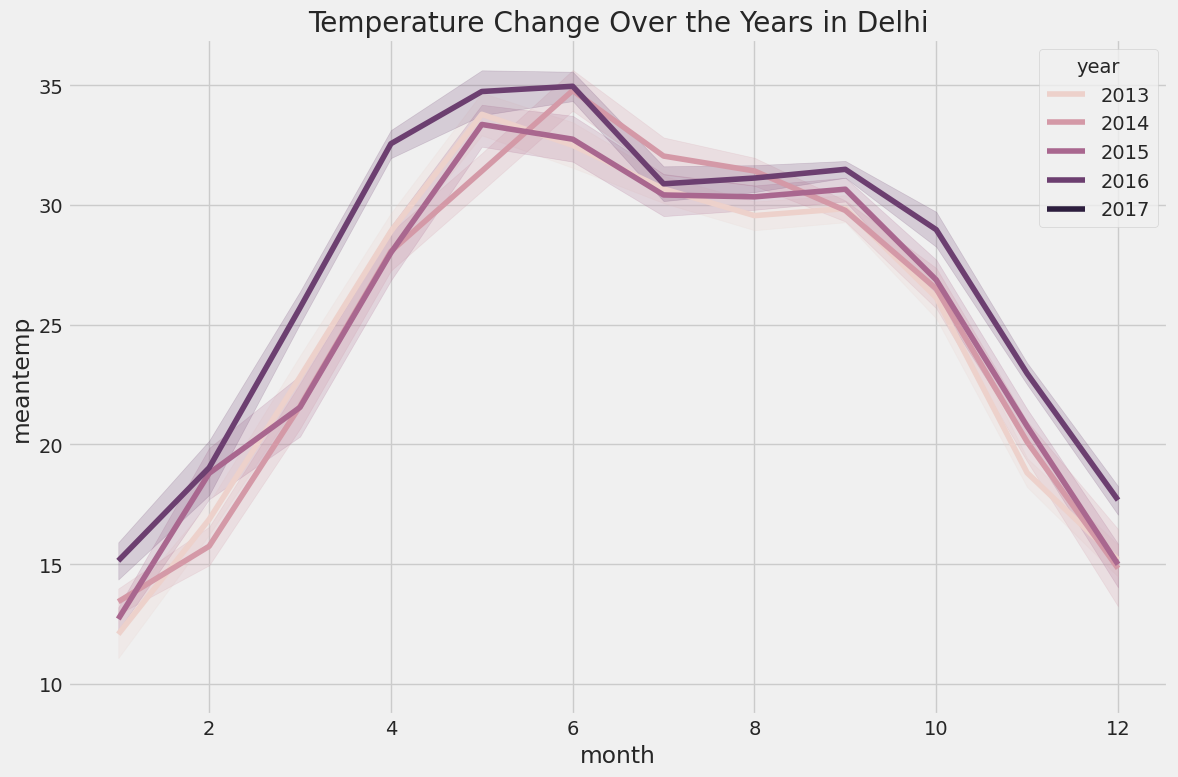

In [21]:
plt.style.use('fivethirtyeight')
sns.lineplot(df, x='month', y='meantemp', hue='year')
plt.title('Temperature Change Over the Years in Delhi')
plt.tight_layout()

## 4. Weather Forecasting
Let's move to the task of weather forecasting. I will be using the Facebook Prophet library to forecast the temperature.

In [22]:
forecast_df = df.rename(columns={'date': 'ds', 'meantemp': 'y'})

In [23]:
forecast_df.head()

,ds,y,humidity,wind_speed,meanpressure,year,month
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1


In [24]:
model = Prophet()
model.fit(forecast_df)

15:58:06 - cmdstanpy - INFO - Chain [1] start processing
15:58:06 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
forecasts = model.make_future_dataframe(periods=365)
predictions = model.predict(forecasts)

In [26]:
plot_plotly(model, predictions)

## 5. Conclusion
In this notebook, we loaded and explored daily climate data for New Delhi, visualized key patterns, and trained a Prophet model to forecast temperature. The workflow covered data preparation, exploratory analysis, and end‑to‑end forecasting in Python.

Key insights:
- Temperature and humidity show a clear negative relationship.
- Strong seasonal patterns are present across years, which the model leverages.
- The baseline forecast captures trend and seasonality but may smooth over extremes.

Future improvements:
- Add features and regressors (e.g., humidity, wind, rainfall, holidays) to enrich the model.
- Compare models (Prophet, SARIMA, XGBoost, LSTM) and perform robust cross‑validation.
- Tune hyperparameters and handle anomalies/missing data more systematically.
- Extend horizons and update the model with more recent observations for better generalization.